In [54]:
import pandas as pd
import numpy as np

In [57]:
p=pd.read_csv(r"C:\Users\26308\Desktop\archive\train.csv")
p.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


在这里我们可以看到PassengerID指的是乘客Id，survived是指存活情况
                Pclass是指乘坐的仓位，Name是指乘客名字
                Sex是指性别，Age是指年龄
                SibSp是指同乘的兄弟姐妹或者配偶，
                Parch是指同乘的父母和子女数量，
                Ticket是指票的等级，
                Fare是指票价，Cabin是指仓位号，
                Embarked是指登船港口

In [6]:
p.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


数据集总共有891个数据，可以看到Survived的均值为0.38，可以看出存活的概率为38%。同时看到Fare存在512的极端值，并且它的标准差高达50，，可以看出数据非常分散，并且均值大于中位数，可知Fare数据右偏分布。同时可以看出大部分人基本都是一个人出行很少携带家人

In [5]:
p.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

可以看到Age存在177的缺失值，可以通过均值去填充，避免出现样本量过少。
而Embarked可以通过众数去填充
仓位的缺失值过多，不建议通过平均数或众数去补充，当下不将该值作为预测因数

In [58]:
p.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
p['Age']=p['Age'].fillna(p['Age'].mean())

In [60]:
p.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
p.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

可见，通过fillna方法，我们把Age的缺失值补充完

In [14]:
p['Embarked']=p['Embarked'].fillna(p['Embarked'].mode()[0])

p.isnull().sum()

In [61]:
p=p.drop(columns='Cabin')

In [62]:
p

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


通过drop函数将Carbin去掉了

In [22]:
p.groupby("Sex")['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

可以看出女性的存活率比男性的存活率要高

In [23]:
p.groupby("Pclass")['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

同时我们可以看出仓位等级更高的存活率更高

In [27]:
d=[0,18,60,float('inf')]
dd=['kid','midd','old']
p['kind']=pd.cut(p['Age'],bins=d,labels=dd,right=True)

我们将cut进行箱型排序，分划成小孩，成人和老人

In [28]:
p.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,kind
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,midd
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,midd
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,midd
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,midd
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,midd


In [29]:
acc=p.groupby('kind')['Survived'].sum()/p.groupby('kind')['Survived'].count()

C:\Users\26308\AppData\Local\Temp\ipykernel_208680\559731255.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc=p.groupby('kind')['Survived'].sum()/p.groupby('kind')['Survived'].count()


In [30]:
acc

kind
kid     0.503597
midd    0.365753
old     0.227273
Name: Survived, dtype: float64

可以看到小孩的存活率远高于成人和老人

In [31]:
p[["Fare", "Survived"]].head(10)

,Fare,Survived
0,7.2500,0
1,71.2833,1
2,7.9250,1
3,53.1000,1
4,8.0500,0
5,8.4583,0
6,51.8625,0
7,21.0750,0
8,11.1333,1
9,30.0708,1


In [32]:
p.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

同样存活的人，他们的平均票价更高

In [33]:
p['df_bin']=pd.qcut(p['Fare'],4)
p.groupby('df_bin')['Survived'].mean()

C:\Users\26308\AppData\Local\Temp\ipykernel_208680\343900117.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p.groupby('df_bin')['Survived'].mean()


df_bin
(-0.001, 7.91]     0.197309
(7.91, 14.454]     0.303571
(14.454, 31.0]     0.454955
(31.0, 512.329]    0.581081
Name: Survived, dtype: float64

C:\Users\26308\AppData\Local\Temp\ipykernel_208680\2121460738.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p.groupby("df_bin")["Survived"].mean().plot(kind="bar")


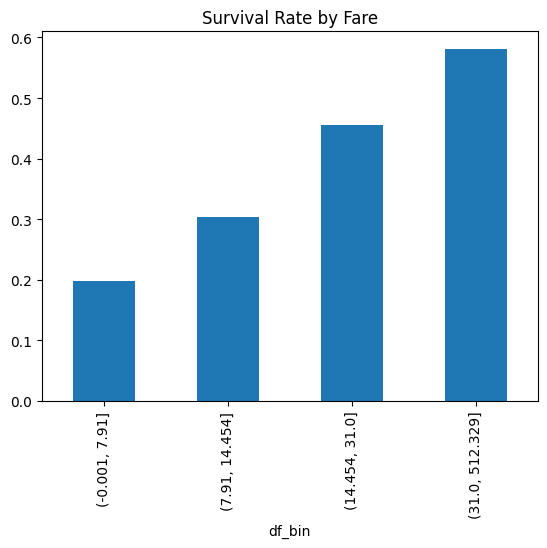

In [35]:
import matplotlib.pyplot as plt

p.groupby("df_bin")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Fare")
plt.show()

In [37]:
p.groupby(["Pclass", "df_bin"])["Survived"].mean()

C:\Users\26308\AppData\Local\Temp\ipykernel_208680\3354026080.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p.groupby(["Pclass", "df_bin"])["Survived"].mean()


Pclass  df_bin         
1       (-0.001, 7.91]     0.000000
        (7.91, 14.454]          NaN
        (14.454, 31.0]     0.529412
        (31.0, 512.329]    0.685535
2       (-0.001, 7.91]     0.000000
        (7.91, 14.454]     0.383721
        (14.454, 31.0]     0.600000
        (31.0, 512.329]    0.545455
3       (-0.001, 7.91]     0.208531
        (7.91, 14.454]     0.253623
        (14.454, 31.0]     0.316832
        (31.0, 512.329]    0.195122
Name: Survived, dtype: float64

In [39]:
p['Fare_z']=(p['Fare']-p['Fare'].mean())/p['Fare'].std()#数据标准化

In [40]:
o=p[p['Fare_z'].abs()>3]#异常值分析，找出异常值，富豪这些是属于异常值，当不可以去掉，有其存在的意义

In [41]:
o

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,kind,df_bin,Fare_z
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000000,3,2,19950,263.0000,S,midd,"(31.0, 512.329]",4.644393
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.000000,3,2,19950,263.0000,S,midd,"(31.0, 512.329]",4.644393
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.000000,0,1,PC 17558,247.5208,C,midd,"(31.0, 512.329]",4.332899
258,259,1,1,"Ward, Miss. Anna",female,35.000000,0,0,PC 17755,512.3292,C,midd,"(31.0, 512.329]",9.661740
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.000000,0,1,PC 17558,247.5208,C,midd,"(31.0, 512.329]",4.332899
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.000000,2,2,PC 17608,262.3750,C,kid,"(31.0, 512.329]",4.631815
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.000000,3,2,19950,263.0000,S,midd,"(31.0, 512.329]",4.644393
377,378,0,1,"Widener, Mr. Harry Elkins",male,27.000000,0,2,113503,211.5000,C,midd,"(31.0, 512.329]",3.608038
380,381,1,1,"Bidois, Miss. Rosalie",female,42.000000,0,0,PC 17757,227.5250,C,midd,"(31.0, 512.329]",3.930516
438,439,0,1,"Fortune, Mr. Mark",male,64.000000,1,4,19950,263.0000,S,old,"(31.0, 512.329]",4.644393


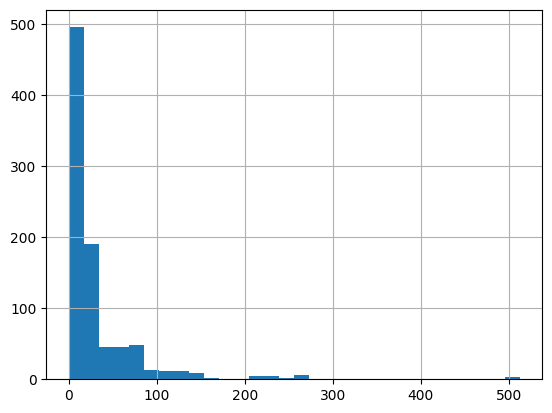

In [42]:
p['Fare'].hist(bins=30)
plt.show()

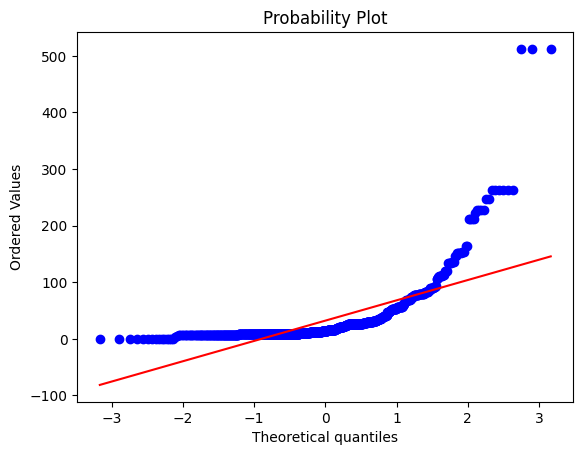

In [44]:
import scipy.stats as stats

stats.probplot(p["Fare"], dist="norm", plot=plt)
plt.show()

In [45]:
p["Fare_log"] = np.log(p["Fare"] + 1)#偏态数据处理

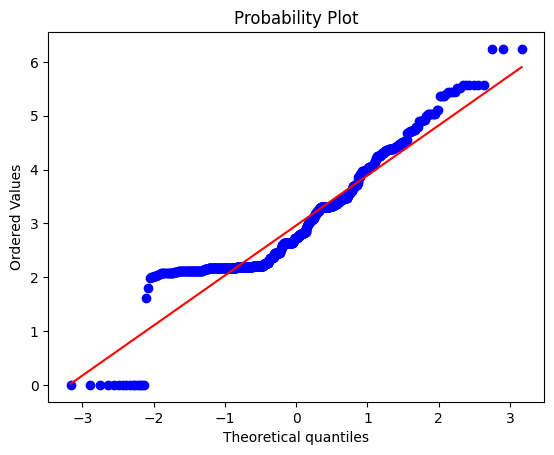

In [46]:
stats.probplot(p["Fare_log"], dist="norm", plot=plt)
plt.show()

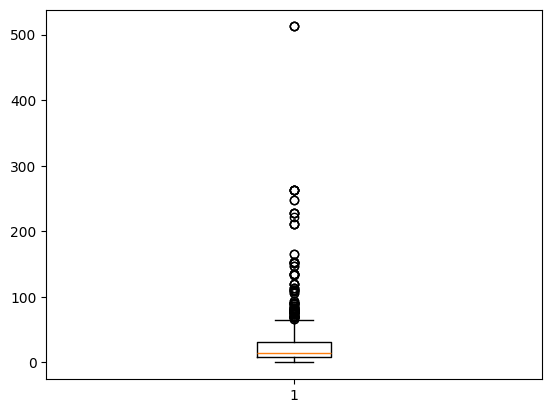

In [47]:
plt.boxplot(p['Fare'])
plt.show()

In [51]:
q1=p['Fare'].quantile(0.25)
q3=p['Fare'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
large=q3+1.5*iqr
oo=p[(p['Fare']<lower)|(p['Fare']>large)]
oo#IQR 方法，不需要正态分布，适合全部

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,kind,df_bin,Fare_z,Fare_log
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,midd,"(31.0, 512.329]",0.786404,4.280593
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000000,3,2,19950,263.0000,S,midd,"(31.0, 512.329]",4.644393,5.575949
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,29.699118,1,0,PC 17569,146.5208,C,midd,"(31.0, 512.329]",2.300437,4.993969
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.000000,1,0,PC 17604,82.1708,C,midd,"(31.0, 512.329]",1.005497,4.420896
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.000000,1,0,PC 17572,76.7292,C,midd,"(31.0, 512.329]",0.895994,4.353231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,29.699118,8,2,CA. 2343,69.5500,S,midd,"(31.0, 512.329]",0.751524,4.256322
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,29.699118,1,0,17453,89.1042,C,midd,"(31.0, 512.329]",1.145020,4.500967
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.000000,1,1,36928,164.8667,S,midd,"(31.0, 512.329]",2.669618,5.111184
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29.699118,8,2,CA. 2343,69.5500,S,midd,"(31.0, 512.329]",0.751524,4.256322


In [52]:
oo.count()

PassengerId    116
Survived       116
Pclass         116
Name           116
Sex            116
Age            116
SibSp          116
Parch          116
Ticket         116
Fare           116
Embarked       116
kind           116
df_bin         116
Fare_z         116
Fare_log       116
dtype: int64

In [53]:
o.count()

PassengerId    20
Survived       20
Pclass         20
Name           20
Sex            20
Age            20
SibSp          20
Parch          20
Ticket         20
Fare           20
Embarked       20
kind           20
df_bin         20
Fare_z         20
dtype: int64

p['Sex'] = p['Sex'].map({'female': 1, 'male': 0})

In [65]:
p['Sex'] = p['Sex'].map({'female': 1, 'male': 0})

In [66]:
p.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


女性存活率更高。
高舱位的乘客存活率较高。
票价高的乘客通常存活率较高。
对性别进行特征处理

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 特征选择
X = p[['Pclass', 'Sex', 'Age', 'Fare']]
y = p['Survived']

# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 预测和评估
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"模型准确率: {accuracy:.2f}")

模型准确率: 0.80


# Titanic 数据分析报告

## 1. 项目背景和目标
**目标**：预测 Titanic 乘客的存活率，并分析哪些特征对存活率有显著影响。

## 2. 数据概述
数据包含 891 名乘客的基本信息。主要特征包括性别、舱位、年龄、票价等。

## 3. 数据清洗和预处理
- 填充缺失值：年龄使用均值填充，Embarked 使用最常见值填充。
- 处理异常值：通过 IQR 方法剔除票价的极端值。
- 性别转换：将性别从字符型转换为数值型。

## 4. 探索性数据分析（EDA）
- 女性的存活率远高于男性。
- 一等舱乘客的存活率显著高于三等舱。
- 票价高的乘客存活率较高。

## 5. 建模与评估
使用逻辑回归模型，准确率为 0.79。

## 6. 结论与建议
- 性别、舱位和票价是存活率的显著影响因素。
- 对于救援计划，女性和高舱位乘客应优先考虑。
